In [1]:
%reload_ext autoreload
%autoreload 2

# nasa-impact/nasa-smd-IR-benchmark 

In [2]:
from datasets import load_dataset, concatenate_datasets
from huggingface_hub import hf_hub_download
import json
import pandas as pd
from datasets import Dataset, DatasetDict


dataset = load_dataset("nasa-impact/nasa-smd-IR-benchmark")
dataset = concatenate_datasets(list(dataset.values()))

df = dataset.to_pandas()

df.head()


,query-id,corpus-id,score
0,67,72915,1
1,239,37223,1
2,495,250048,1
3,283,125841,1
4,200,213374,1


In [5]:
# Download queries.jsonl from the dataset repo
queries_path = hf_hub_download(
    repo_id="nasa-impact/nasa-smd-IR-benchmark",
    filename="queries.jsonl",
    repo_type="dataset"
)

# Download corpus.jsonl similarly
corpus_path = hf_hub_download(
    repo_id="nasa-impact/nasa-smd-IR-benchmark",
    filename="corpus.jsonl",
    repo_type="dataset"
)

queries_df = pd.read_json(queries_path, lines=True)
queries_df.rename(columns={"_id": "query-id", "text": "query"}, inplace=True)

corpus_df = pd.read_json(corpus_path, lines=True)
corpus_df.rename(columns={"_id": "corpus-id", "text": "corpus"}, inplace=True)

# Join for validation set
df = df.merge(queries_df, on="query-id", how="left")
df = df.merge(corpus_df, on="corpus-id", how="left")
df.rename({"query": "anchor", "corpus": "positive"}, axis=1, inplace=True)
df = df[["anchor", "positive"]]
df.head()


hf_ds = Dataset.from_pandas(df, preserve_index=False)
hf_dd = DatasetDict({"nasa-smd-IR-benchmark": hf_ds})

In [ ]:
hf_dd

In [3]:
from sentence_transformers import SentenceTransformer

modernbert_model_before_traning = SentenceTransformer("nomic-ai/modernbert-embed-base")
indus_st_v2_model_before_traning = SentenceTransformer("nasa-impact/nasa-smd-ibm-st-v2")

# modernbert_model = SentenceTransformer("/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_100__nsrc_None/timestamp_20250512_13-45-10/modernbert-embed-base/checkpoints/checkpoint-1300")
# indus_st_v2_model = SentenceTransformer("/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_100__nsrc_None/timestamp_20250512_13-49-27/nasa-smd-ibm-st-v2/checkpoints/checkpoint-1300")
indus_sde_v2_st_model = SentenceTransformer("/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_None__nsrc_None/timestamp_20250505_16-10-36/indus-sde-v0.2/checkpoints/checkpoint-166000")


models = {
    "ModernBERT_ST_original": modernbert_model_before_traning,
    "Indus_ST_original": indus_st_v2_model_before_traning,
    # "ModernBERT_ST_fine_tuned": modernbert_model,
    # "Indus_ST_fine_tuned": indus_st_v2_model,
    "Indus_SDE_ST_intermediate_checkpoint_166k": indus_sde_v2_st_model
}

In [9]:
from utils import prepare_evaluators

evaluator = prepare_evaluators(hf_dd, max_per_split=None)
evals = {m_str: evaluator(m)  for m_str, m in models.items() }

Prepared SequentialEvaluator with: ['ir_evaluator', 'mnr_loss']


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:28<00:00, 28.18s/it]


...

Corpus Chunks: 100%|██████████| 1/1 [00:14<00:00, 14.80s/it]


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:15<00:00, 15.28s/it]


## Retrival Time evals

In [10]:
from utils import RetrievalTimer
time_reports = {m_str: RetrievalTimer(m, corpus=hf_ds["positive"], queries=hf_ds["anchor"], top_k=10).run()  for m_str, m in models.items() }
evals = {m_str: {**evals[m_str], **time_reports[m_str]} for m_str in evals.keys()}

In [11]:
evals["Indus_ST_original"]

{'ir_evaluator_cosine_accuracy@1': 0.25903614457831325,
 'ir_evaluator_cosine_accuracy@5': 0.7951807228915663,
 'ir_evaluator_cosine_accuracy@10': 0.8493975903614458,
 'ir_evaluator_cosine_precision@1': 0.25903614457831325,
 'ir_evaluator_cosine_precision@5': 0.15903614457831322,
 'ir_evaluator_cosine_precision@10': 0.08493975903614458,
 'ir_evaluator_cosine_recall@1': 0.25903614457831325,
 'ir_evaluator_cosine_recall@5': 0.7951807228915663,
 'ir_evaluator_cosine_recall@10': 0.8493975903614458,
 'ir_evaluator_cosine_ndcg@1': 0.25903614457831325,
 'ir_evaluator_cosine_ndcg@5': 0.5522481402347181,
 'ir_evaluator_cosine_ndcg@10': 0.5703845009815482,
 'ir_evaluator_cosine_mrr@1': 0.25903614457831325,
 'ir_evaluator_cosine_mrr@5': 0.4702476572958508,
 'ir_evaluator_cosine_mrr@10': 0.47809332568368773,
 'ir_evaluator_cosine_map@1': 0.25903614457831325,
 'ir_evaluator_cosine_map@5': 0.47024765729585005,
 'ir_evaluator_cosine_map@10': 0.4780933256836871,
 'mnr_loss/avg': 1.4328865483403206,
 '

In [16]:
evals["Indus_SDE_ST_intermediate_checkpoint_166k"]

{'ir_evaluator_cosine_accuracy@1': 0.3032128514056225,
 'ir_evaluator_cosine_accuracy@5': 0.8694779116465864,
 'ir_evaluator_cosine_accuracy@10': 0.9317269076305221,
 'ir_evaluator_cosine_precision@1': 0.3032128514056225,
 'ir_evaluator_cosine_precision@5': 0.17389558232931726,
 'ir_evaluator_cosine_precision@10': 0.09317269076305222,
 'ir_evaluator_cosine_recall@1': 0.3032128514056225,
 'ir_evaluator_cosine_recall@5': 0.8694779116465864,
 'ir_evaluator_cosine_recall@10': 0.9317269076305221,
 'ir_evaluator_cosine_ndcg@1': 0.3032128514056225,
 'ir_evaluator_cosine_ndcg@5': 0.6157237462922521,
 'ir_evaluator_cosine_ndcg@10': 0.636381921494251,
 'ir_evaluator_cosine_mrr@1': 0.3032128514056225,
 'ir_evaluator_cosine_mrr@5': 0.5297858099062924,
 'ir_evaluator_cosine_mrr@10': 0.538627525976924,
 'ir_evaluator_cosine_map@1': 0.3032128514056225,
 'ir_evaluator_cosine_map@5': 0.5297858099062918,
 'ir_evaluator_cosine_map@10': 0.5386275259769235,
 'mnr_loss/avg': 1.0289027132093906,
 'mnr_loss/s

In [ ]:
prev_evals = {'ModernBERT_ST_original': {'ir_evaluator_cosine_accuracy@1': 0.26706827309236947, 'ir_evaluator_cosine_accuracy@5': 0.8353413654618473, 'ir_evaluator_cosine_accuracy@10': 0.9036144578313253, 'ir_evaluator_cosine_precision@1': 0.26706827309236947, 'ir_evaluator_cosine_precision@5': 0.1670682730923695, 'ir_evaluator_cosine_precision@10': 0.09036144578313253, 'ir_evaluator_cosine_recall@1': 0.26706827309236947, 'ir_evaluator_cosine_recall@5': 0.8353413654618473, 'ir_evaluator_cosine_recall@10': 0.9036144578313253, 'ir_evaluator_cosine_ndcg@1': 0.26706827309236947, 'ir_evaluator_cosine_ndcg@5': 0.5839296131091536, 'ir_evaluator_cosine_ndcg@10': 0.6067956965836963, 'ir_evaluator_cosine_mrr@1': 0.26706827309236947, 'ir_evaluator_cosine_mrr@5': 0.4985274431057573, 'ir_evaluator_cosine_mrr@10': 0.5084217823675662, 'ir_evaluator_cosine_map@1': 0.26706827309236947, 'ir_evaluator_cosine_map@5': 0.4985274431057563, 'ir_evaluator_cosine_map@10': 0.5084217823675655, 'mnr_loss/avg': 1.3794464990496635, 'mnr_loss/sum': 22.071143984794617, 'sequential_score': 1.3794464990496635, 'corpus_encode_s': 36.19802425708622, 'avg_query_encode_s': 0.016407538299826555, 'avg_query_search_s': 6.732928807880864e-05, 'avg_query_retrieval_s': 0.01647486758790536, 'total_query_time_s': 8.20448405877687}, 'Indus_ST_original': {'ir_evaluator_cosine_accuracy@1': 0.25301204819277107, 'ir_evaluator_cosine_accuracy@5': 0.7971887550200804, 'ir_evaluator_cosine_accuracy@10': 0.8493975903614458, 'ir_evaluator_cosine_precision@1': 0.25301204819277107, 'ir_evaluator_cosine_precision@5': 0.15943775100401605, 'ir_evaluator_cosine_precision@10': 0.08493975903614458, 'ir_evaluator_cosine_recall@1': 0.25301204819277107, 'ir_evaluator_cosine_recall@5': 0.7971887550200804, 'ir_evaluator_cosine_recall@10': 0.8493975903614458, 'ir_evaluator_cosine_ndcg@1': 0.25301204819277107, 'ir_evaluator_cosine_ndcg@5': 0.5498379932558063, 'ir_evaluator_cosine_ndcg@10': 0.5672590785265158, 'ir_evaluator_cosine_mrr@1': 0.25301204819277107, 'ir_evaluator_cosine_mrr@5': 0.4663989290495321, 'ir_evaluator_cosine_mrr@10': 0.4739099254159502, 'ir_evaluator_cosine_map@1': 0.25301204819277107, 'ir_evaluator_cosine_map@5': 0.46639892904953145, 'ir_evaluator_cosine_map@10': 0.4739099254159495, 'mnr_loss/avg': 1.4328865483403206, 'mnr_loss/sum': 22.92618477344513, 'sequential_score': 1.4328865483403206, 'corpus_encode_s': 20.9051608229056, 'avg_query_encode_s': 0.009427725974223521, 'avg_query_search_s': 4.810836478454401e-05, 'avg_query_retrieval_s': 0.009475834339008064, 'total_query_time_s': 4.718965500826016}, 'ModernBERT_ST_fine_tuned': {'ir_evaluator_cosine_accuracy@1': 0.28112449799196787, 'ir_evaluator_cosine_accuracy@5': 0.8453815261044176, 'ir_evaluator_cosine_accuracy@10': 0.9116465863453815, 'ir_evaluator_cosine_precision@1': 0.28112449799196787, 'ir_evaluator_cosine_precision@5': 0.16907630522088352, 'ir_evaluator_cosine_precision@10': 0.09116465863453817, 'ir_evaluator_cosine_recall@1': 0.28112449799196787, 'ir_evaluator_cosine_recall@5': 0.8453815261044176, 'ir_evaluator_cosine_recall@10': 0.9116465863453815, 'ir_evaluator_cosine_ndcg@1': 0.28112449799196787, 'ir_evaluator_cosine_ndcg@5': 0.5991280242389027, 'ir_evaluator_cosine_ndcg@10': 0.6211099307767558, 'ir_evaluator_cosine_mrr@1': 0.28112449799196787, 'ir_evaluator_cosine_mrr@5': 0.5151941097724241, 'ir_evaluator_cosine_mrr@10': 0.5245856441639581, 'ir_evaluator_cosine_map@1': 0.28112449799196787, 'ir_evaluator_cosine_map@5': 0.515194109772423, 'ir_evaluator_cosine_map@10': 0.5245856441639574, 'mnr_loss/avg': 1.2230549529194832, 'mnr_loss/sum': 19.56887924671173, 'sequential_score': 1.2230549529194832, 'corpus_encode_s': 36.0798032770399, 'avg_query_encode_s': 0.015805460183028447, 'avg_query_search_s': 4.9643902515760624e-05, 'avg_query_retrieval_s': 0.015855104085544205, 'total_query_time_s': 7.895841834601015}, 'Indus_ST_fine_tuned': {'ir_evaluator_cosine_accuracy@1': 0.2429718875502008, 'ir_evaluator_cosine_accuracy@5': 0.7991967871485943, 'ir_evaluator_cosine_accuracy@10': 0.8634538152610441, 'ir_evaluator_cosine_precision@1': 0.2429718875502008, 'ir_evaluator_cosine_precision@5': 0.15983935742971886, 'ir_evaluator_cosine_precision@10': 0.08634538152610442, 'ir_evaluator_cosine_recall@1': 0.2429718875502008, 'ir_evaluator_cosine_recall@5': 0.7991967871485943, 'ir_evaluator_cosine_recall@10': 0.8634538152610441, 'ir_evaluator_cosine_ndcg@1': 0.2429718875502008, 'ir_evaluator_cosine_ndcg@5': 0.5478180943525005, 'ir_evaluator_cosine_ndcg@10': 0.5692732244214763, 'ir_evaluator_cosine_mrr@1': 0.2429718875502008, 'ir_evaluator_cosine_mrr@5': 0.46285140562249066, 'ir_evaluator_cosine_mrr@10': 0.4721106648817498, 'ir_evaluator_cosine_map@1': 0.2429718875502008, 'ir_evaluator_cosine_map@5': 0.46285140562248994, 'ir_evaluator_cosine_map@10': 0.47211066488174924, 'mnr_loss/avg': 1.3364169783890247, 'mnr_loss/sum': 21.382671654224396, 'sequential_score': 1.3364169783890247, 'corpus_encode_s': 20.99083264893852, 'avg_query_encode_s': 0.009501617924538422, 'avg_query_search_s': 4.817208464081627e-05, 'avg_query_retrieval_s': 0.009549790009179238, 'total_query_time_s': 4.755795424571261}, 'Indus_SDE_ST_intermediate_checkpoint_82k': {'ir_evaluator_cosine_accuracy@1': 0.3032128514056225, 'ir_evaluator_cosine_accuracy@5': 0.8714859437751004, 'ir_evaluator_cosine_accuracy@10': 0.929718875502008, 'ir_evaluator_cosine_precision@1': 0.3032128514056225, 'ir_evaluator_cosine_precision@5': 0.1742971887550201, 'ir_evaluator_cosine_precision@10': 0.09297188755020082, 'ir_evaluator_cosine_recall@1': 0.3032128514056225, 'ir_evaluator_cosine_recall@5': 0.8714859437751004, 'ir_evaluator_cosine_recall@10': 0.929718875502008, 'ir_evaluator_cosine_ndcg@1': 0.3032128514056225, 'ir_evaluator_cosine_ndcg@5': 0.6165005591581849, 'ir_evaluator_cosine_ndcg@10': 0.6359738049987744, 'ir_evaluator_cosine_mrr@1': 0.3032128514056225, 'ir_evaluator_cosine_mrr@5': 0.5301874163319953, 'ir_evaluator_cosine_mrr@10': 0.5386052145088295, 'ir_evaluator_cosine_map@1': 0.3032128514056225, 'ir_evaluator_cosine_map@5': 0.5301874163319946, 'ir_evaluator_cosine_map@10': 0.538605214508829, 'mnr_loss/avg': 1.0288898069411516, 'mnr_loss/sum': 16.462236911058426, 'sequential_score': 1.0288898069411516, 'corpus_encode_s': 21.90816739317961, 'avg_query_encode_s': 0.009297530726907423, 'avg_query_search_s': 4.835836364921317e-05, 'avg_query_retrieval_s': 0.009345889090556636, 'total_query_time_s': 4.654252767097205}}

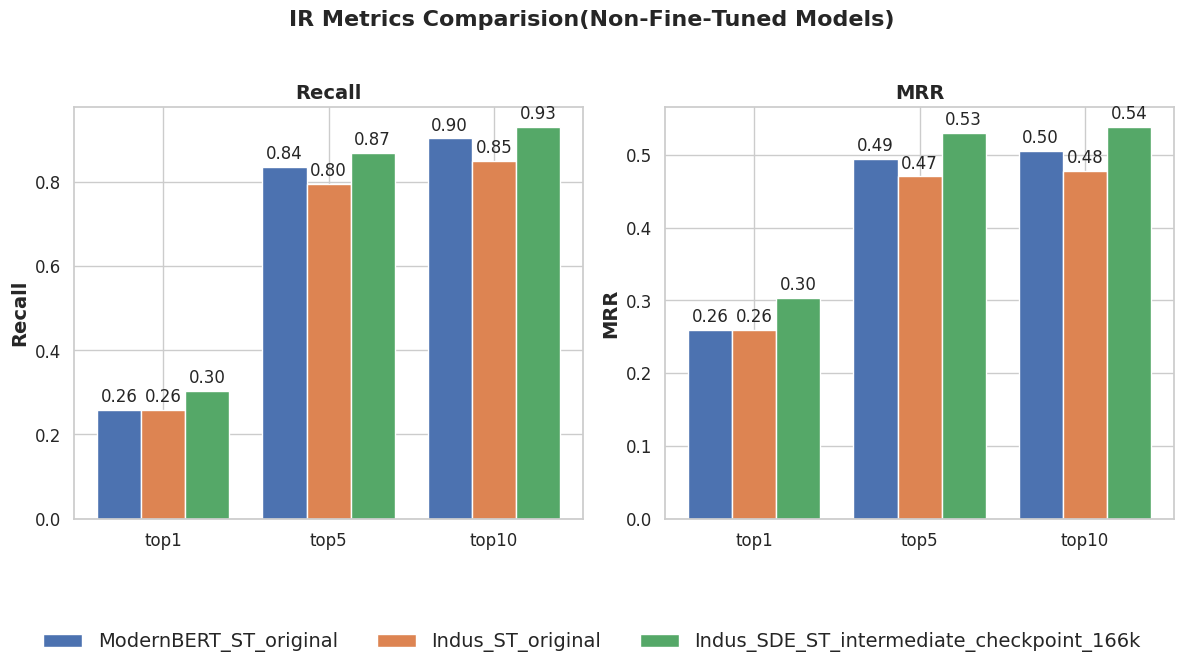

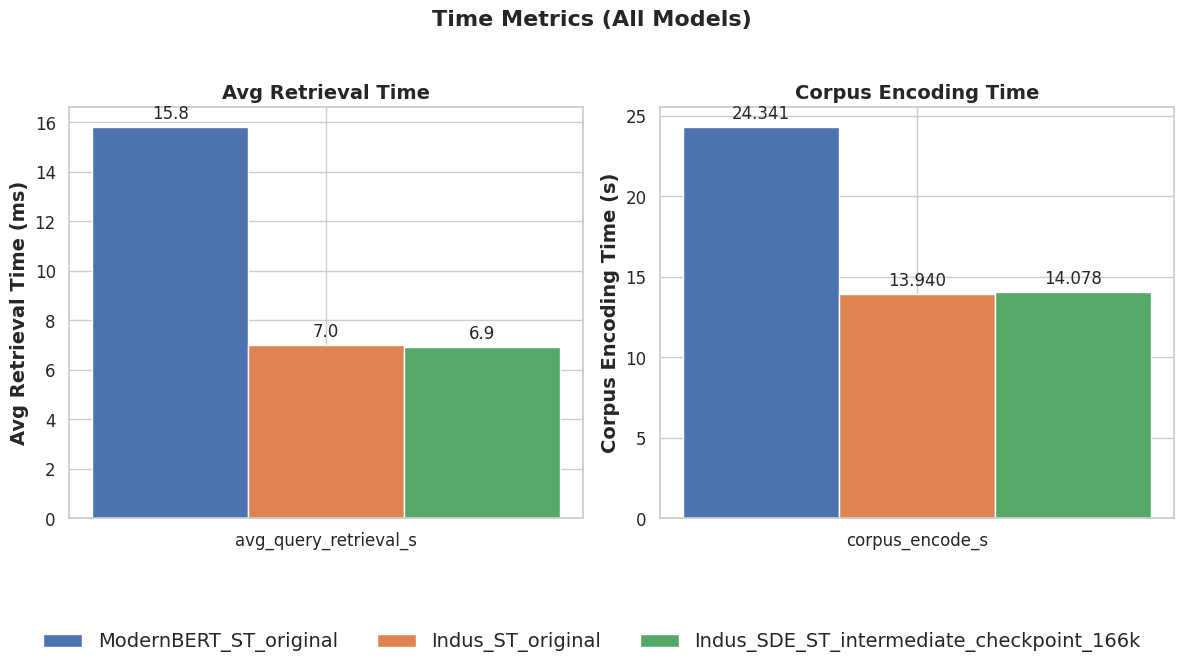

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─── Settings ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="deep")
FONT_SIZE = 14
TICK_FONT_SIZE = FONT_SIZE - 2

# ─── 1) Specify exact model order ────────────────────────────────────────────
desired_order = [
    'indus_st_v2_original',
    'indus_st_v2_fine_tuned',
    'modernbert_st_original',
    'modernbert_st_fine_tuned',
    'indus_sde_based'
]
model_names = []
for name in desired_order:
    for real in evals:
        if real.lower() == name.lower():
            model_names.append(real)
            break
for real in evals:
    if real not in model_names:
        model_names.append(real)

non_finetuned_models = [m for m in model_names if 'fine_tuned' not in m.lower()]
finetuned_models    = [m for m in model_names if 'fine_tuned' in m.lower()]

# ─── 2) Define metric groups (MAP removed) ───────────────────────────────────
main_metric_groups = {
    'Recall': sorted(
        [k for k in evals[model_names[0]] if 'recall' in k],
        key=lambda x: int(x.split('@')[1])
    ),
    'MRR': sorted(
        [k for k in evals[model_names[0]] if 'mrr' in k],
        key=lambda x: int(x.split('@')[1])
    )
}
time_metric_groups = {
    'Avg Retrieval Time':   ['avg_query_retrieval_s'],
    'Corpus Encoding Time': ['corpus_encode_s']
}

# ─── 3) Plot 1: Main metrics for non-fine-tuned models ───────────────────────
fig1, axes1 = plt.subplots(1, len(main_metric_groups), figsize=(6 * len(main_metric_groups), 6), squeeze=False)
axes1 = axes1[0]
for ax, (title, keys) in zip(axes1, main_metric_groups.items()):
    idx = np.arange(len(keys))
    width = 0.8 / len(non_finetuned_models)
    for i, m in enumerate(non_finetuned_models):
        vals = [evals[m][k] for k in keys]
        bars = ax.bar(idx + i * width, vals, width, label=m)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=TICK_FONT_SIZE)
    ax.set_title(title,       fontsize=FONT_SIZE,   fontweight='bold')
    ax.set_ylabel(title,      fontsize=FONT_SIZE,   fontweight='bold')
    ax.set_xticks(idx + width*(len(non_finetuned_models)-1)/2)
    ax.set_xticklabels([f"top{k.split('@')[-1]}" for k in keys], fontsize=TICK_FONT_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

leg1 = fig1.legend(non_finetuned_models, loc='lower center', ncol=len(non_finetuned_models),
                   bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZE, frameon=False)
leg1.set_title("")
fig1.suptitle("IR Metrics Comparision(Non‑Fine‑Tuned Models)", fontsize=FONT_SIZE+2, fontweight='bold')
fig1.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ─── 4) Plot 2: Time metrics for all models (retrieval in ms) ───────────────
fig2, axes2 = plt.subplots(1, len(time_metric_groups), figsize=(6 * len(time_metric_groups), 6), squeeze=False)
axes2 = axes2[0]
for ax, (title, keys) in zip(axes2, time_metric_groups.items()):
    idx = np.arange(len(keys))
    width = 0.8 / len(model_names)
    for i, m in enumerate(model_names):
        if title == 'Avg Retrieval Time':
            vals = [evals[m][k] * 1000 for k in keys]  # seconds→ms
            fmt = "%.1f"
            unit = "ms"
        else:
            vals = [evals[m][k] for k in keys]
            fmt = "%.3f"
            unit = "s"
        bars = ax.bar(idx + i * width, vals, width, label=m)
        ax.bar_label(bars, fmt=fmt, padding=3, fontsize=TICK_FONT_SIZE)
    ax.set_title(title,       fontsize=FONT_SIZE,   fontweight='bold')
    ax.set_ylabel(f"{title} ({unit})", fontsize=FONT_SIZE, fontweight='bold')
    ax.set_xticks(idx + width*(len(model_names)-1)/2)
    ax.set_xticklabels(keys, fontsize=TICK_FONT_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

leg2 = fig2.legend(model_names, loc='lower center', ncol=len(model_names),
                   bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZE, frameon=False)
leg2.set_title("")
fig2.suptitle("Time Metrics (All Models)", fontsize=FONT_SIZE+2, fontweight='bold')
fig2.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ─── 5) Plot 3: Main metrics for fine-tuned models ───────────────────────────
if finetuned_models:
    fig3, axes3 = plt.subplots(1, len(main_metric_groups), figsize=(6 * len(main_metric_groups), 6), squeeze=False)
    axes3 = axes3[0]
    for ax, (title, keys) in zip(axes3, main_metric_groups.items()):
        idx = np.arange(len(keys))
        width = 0.8 / len(finetuned_models)
        for i, m in enumerate(finetuned_models):
            vals = [evals[m][k] for k in keys]
            bars = ax.bar(idx + i * width, vals, width, label=m)
            ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=TICK_FONT_SIZE)
        ax.set_title(title,       fontsize=FONT_SIZE,   fontweight='bold')
        ax.set_ylabel(title,      fontsize=FONT_SIZE,   fontweight='bold')
        ax.set_xticks(idx + width*(len(finetuned_models)-1)/2)
        ax.set_xticklabels([f"top{k.split('@')[-1]}" for k in keys], fontsize=TICK_FONT_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

    leg3 = fig3.legend(finetuned_models, loc='lower center', ncol=len(finetuned_models),
                       bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZE, frameon=False)
    leg3.set_title("")
    fig3.suptitle("IR Metrics (Fine‑Tuned Models)", fontsize=FONT_SIZE+2, fontweight='bold')
    fig3.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


# BEIR

In [ ]:
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from beir.datasets.data_loader import GenericDataLoader
from beir import util as beir_util
import os
import pathlib
import logging
from collections import defaultdict
import json

#### Just some setup for logging ####
logging.basicConfig(format='%(asctime)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S',
                    level=logging.INFO)

all_results = {}

split = "test"
ks = [1,3,5,10]

models = {
    "modernbert-embed-base": "nomic-ai/modernbert-embed-base",
    "nasa-smd-ibm-st-v2": "nasa-impact/nasa-smd-ibm-st-v2",
    "indus-sde-st-v0.1": "nasa-impact/indus-sde-st-v0.1"
}

_DATASETS = ["trec-covid", "nfcorpus", "nq", "hotpotqa", "fiqa", 
             "arguana", "webis-touche2020", "dbpedia-entity","scidocs", "fever",
             "climate-fever", "scifact",
              "msmarco", "cqadupstack", "quora"]


# start to evaluate
for dname in _DATASETS:
    if all_results.get(dname) is None:
        all_results[dname] = {}

    url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dname}.zip"
    out_dir = os.path.join(pathlib.Path.cwd(), "datasets")
    data_path = beir_util.download_and_unzip(url, out_dir)

    # Load the dataset using the BEIR loader
    corpus_beir, queries, qrels_beir = GenericDataLoader(data_folder=data_path).load(split="test")

    # The corpus needs to be flattened from Dict[str, Dict[str,str]] to Dict[str, str]
    # We'll concatenate the title and text for each document.
    corpus = {doc_id: (doc.get("title", "") + " " + doc.get("text", "")).strip() for doc_id, doc in corpus_beir.items()}

    # The qrels need to be converted to the relevant_docs format: Dict[str, Set[str]]
    # We'll only consider documents with a relevance score > 0.
    relevant_docs = defaultdict(set)
    for query_id, doc_scores in qrels_beir.items():
        for doc_id, score in doc_scores.items():
            if score > 0:
                relevant_docs[query_id].add(doc_id)

    evaluator = InformationRetrievalEvaluator(
                    queries=queries,
                    corpus=corpus,
                    relevant_docs=relevant_docs,
                    name=f"{dname}_evaluator",
                    batch_size=8,
                    mrr_at_k=ks,
                    ndcg_at_k=ks,
                    accuracy_at_k=ks,
                    precision_recall_at_k=ks,
                    map_at_k=ks,
                    show_progress_bar=True,
                    write_csv=True,
                )
    

    for model_name, model_path in models.items():
        print(f"Evaluating model: {model_name}")
        model = SentenceTransformer(model_path)
        all_results[dname][model_name] = evaluator(model)


with open("BEIR_eval_dump.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=4)
    


2025-06-09 12:42:00 - Downloading trec-covid.zip ...


/nas/rhome/sawale/indus_traning/sentense_transformers/eval/datasets/trec-covid.zip:   0%|          | 0.00/70.5…

2025-06-09 12:42:20 - Unzipping trec-covid.zip ...
2025-06-09 12:42:22 - Loading Corpus...


  0%|          | 0/171332 [00:00<?, ?it/s]

2025-06-09 12:42:23 - Loaded 171332 TEST Documents.
2025-06-09 12:42:23 - Doc Example: {'text': 'OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, Jeddah, Saudi Arabia. METHODS: Patients with positive M. pneumoniae cultures from respiratory specimens from January 1997 through December 1998 were identified through the Microbiology records. Charts of patients were reviewed. RESULTS: 40 patients were identified, 33 (82.5%) of whom required admission. Most infections (92.5%) were community-acquired. The infection affected all age groups but was most common in infants (32.5%) and pre-school children (22.5%). It occurred year-round but was most common in the fall (35%) and spring (30%). More than three-quarters of patients (77.5%) had comorbidities. Twenty-four isolates (60%) were associated with pneumonia, 14 (35%) with upper respiratory tract 

Evaluating model: modernbert-embed-base


2025-06-09 12:42:27 - Information Retrieval Evaluation of the model on the trec-covid_evaluator dataset:


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/6250 [00:00<?, ?it/s]